# Glassdoor Data Analyst Job Postings — EDA & Insights

**Purpose:** Explore salary patterns in Data Analyst job postings after the raw dataset has already been cleaned.

**Input:** `DataAnalyst_cleaned.csv`, produced by `01_data_cleaning_portfolio_balanced.ipynb`  
**Output:** insight tables and visuals that can be used in the portfolio case study page.

This notebook focuses on analysis, not cleaning. The cleaning decisions live in the separate cleaning notebook.

## Workflow

1. Load the cleaned dataset
2. Run quick sanity checks
3. Prepare EDA-only fields such as job city/state and skill score
4. Answer four research questions:
   - Does sector influence salary?
   - Do higher-revenue companies ask for more technical skills?
   - Does location still matter for salary?
   - Does company rating relate to pay?
5. Summarize findings, limitations, and next steps

## 1. Setup

Import the main libraries used for analysis and visualization. The notebook keeps the tooling simple: pandas for analysis, matplotlib/seaborn for charts, and scipy for basic statistical tests.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings

from scipy.stats import f_oneway, spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Save portfolio-ready visuals from this notebook
os.makedirs('visuals', exist_ok=True)

## 2. Load the Cleaned Dataset

The cleaned file should already include parsed salary, company size, revenue, seniority, and company age fields. This keeps the EDA notebook focused on insights instead of repeating the cleaning work.

In [2]:
cleaned_path = 'DataAnalyst_cleaned.csv'
df = pd.read_csv(cleaned_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 2,251
Columns: 24


,job title,seniority_level,salary estimate,salary_min,salary_max,salary_avg,job description,rating,company name,location,headquarters,size,size_min,size_max,size_avg,founded,company_age,type of ownership,industry,sector,revenue,revenue_min_millions,revenue_max_millions,revenue_avg_millions
0,"Data Analyst, Center on Immigration and Justic...",mid/unspecified,$37K-$66K (Glassdoor est.),37000,66000,51500,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice,"New York, NY","New York, NY",201 to 500 employees,201.0,500.0,350.0,1961.0,65.0,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),100.0,500.0,300.0
1,Quality Data Analyst,mid/unspecified,$37K-$66K (Glassdoor est.),37000,66000,51500,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York,"New York, NY","New York, NY",10000+ employees,10000.0,NaN,NaN,1893.0,133.0,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),2000.0,5000.0,3500.0
2,"Senior Data Analyst, Insights & Analytics Team...",senior,$37K-$66K (Glassdoor est.),37000,66000,51500,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace,"New York, NY","New York, NY",1001 to 5000 employees,1001.0,5000.0,3000.0,2003.0,23.0,Company - Private,Internet,Information Technology,Not disclosed,NaN,NaN,NaN
3,Data Analyst,mid/unspecified,$37K-$66K (Glassdoor est.),37000,66000,51500,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity,"New York, NY","McLean, VA",201 to 500 employees,201.0,500.0,350.0,2002.0,24.0,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),50.0,100.0,75.0
4,Reporting Data Analyst,mid/unspecified,$37K-$66K (Glassdoor est.),37000,66000,51500,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel,"New York, NY","New York, NY",501 to 1000 employees,501.0,1000.0,750.0,2009.0,17.0,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),100.0,500.0,300.0


## 3. Sanity Check

Before analysis, confirm that the required fields from the cleaning notebook exist. This makes the notebook easier to debug if the cleaned CSV is renamed, moved, or regenerated with a different schema.

In [3]:
required_columns = [
    'job title', 'salary_avg', 'salary_min', 'salary_max',
    'job description', 'rating', 'company name', 'location',
    'size_avg', 'company_age', 'industry', 'sector',
    'revenue_avg_millions'
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
else:
    print("All required columns are present.")

print("\nDataset overview:")
df[required_columns].info()

All required columns are present.

Dataset overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2251 entries, 0 to 2250
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job title             2251 non-null   object 
 1   salary_avg            2251 non-null   int64  
 2   salary_min            2251 non-null   int64  
 3   salary_max            2251 non-null   int64  
 4   job description       2251 non-null   object 
 5   rating                1980 non-null   float64
 6   company name          2251 non-null   object 
 7   location              2251 non-null   object 
 8   size_avg              1672 non-null   float64
 9   company_age           1592 non-null   float64
 10  industry              1899 non-null   object 
 11  sector                1899 non-null   object 
 12  revenue_avg_millions  1285 non-null   float64
dtypes: float64(4), int64(3), object(6)
memory usage: 228.7+ KB


In [4]:
# Quick view of missingness in analysis-relevant fields
analysis_fields = [
    'salary_avg', 'sector', 'industry', 'rating',
    'revenue_avg_millions', 'size_avg', 'company_age', 'location'
]

missing_summary = (
    df[analysis_fields]
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
)
missing_summary.columns = ['field', 'missing_pct']
missing_summary

,field,missing_pct
0,revenue_avg_millions,42.9
1,company_age,29.3
2,size_avg,25.7
3,sector,15.6
4,industry,15.6
5,rating,12.0
6,salary_avg,0.0
7,location,0.0


## 4. Light Feature Preparation for EDA

The cleaning notebook intentionally keeps the dataset general. For this EDA, we add only the fields needed for analysis:

- `job_city` and `job_state` from `location`
- skill category flags and `skill_score` from `job description`

These are analysis features, not raw-data cleaning replacements.

In [5]:
# Split location into city and state for geographic analysis
location_split = df['location'].str.split(',', n=1, expand=True)
df['job_city'] = location_split[0].str.strip()
df['job_state'] = location_split[1].str.strip()

print(df[['location', 'job_city', 'job_state']].head())
print(f"\nUnique states: {df['job_state'].nunique()}")
print(f"Unique cities: {df['job_city'].nunique()}")

       location  job_city job_state
0  New York, NY  New York        NY
1  New York, NY  New York        NY
2  New York, NY  New York        NY
3  New York, NY  New York        NY
4  New York, NY  New York        NY

Unique states: 20
Unique cities: 249


In [6]:
# Skill categories used for technical complexity analysis
skill_keywords = {
    'data_manipulation': ['sql', 'mysql', 'postgresql', 'bigquery', 'pandas', 'excel', 'power query'],
    'programming': ['python', 'r language', 'java', 'scala', 'julia'],
    'visualization': ['tableau', 'power bi', 'looker', 'qlik', 'matplotlib', 'seaborn', 'plotly'],
    'cloud_platforms': ['aws', 'azure', 'gcp', 'google cloud', 'snowflake', 'databricks', 'redshift'],
    'ml_ai': ['machine learning', 'deep learning', 'nlp', 'neural network', 'tensorflow', 'scikit', 'predictive model'],
    'statistics': ['statistics', 'statistical', 'regression', 'hypothesis test', 'a/b test', 'anova', 'probability']
}

def has_skill_category(text, keywords):
    """Return 1 if any keyword from a skill category appears in the job description."""
    if pd.isna(text):
        return 0
    text = str(text).lower()
    return int(any(re.search(r'\b' + re.escape(keyword) + r'\b', text) for keyword in keywords))

# Create one flag per skill category
for category, keywords in skill_keywords.items():
    df[f'skill_{category}'] = df['job description'].apply(lambda x: has_skill_category(x, keywords))

skill_flag_cols = [f'skill_{category}' for category in skill_keywords.keys()]
df['skill_score'] = df[skill_flag_cols].sum(axis=1)

print("Skill score distribution:")
print(df['skill_score'].value_counts().sort_index())
print(f"\nMean skill score: {df['skill_score'].mean():.2f}")

Skill score distribution:
skill_score
0    359
1    625
2    569
3    356
4    222
5     96
6     24
Name: count, dtype: int64

Mean skill score: 1.93


# Research Questions

The analysis is organized around four questions that are easy to explain in a portfolio case study and useful for career-market interpretation.

## RQ1 — Does sector influence salary?

**Question:** How does salary vary across sectors?  
**Why it matters:** Sector is one of the clearest ways to translate job-posting data into career strategy.

**Method:** Filter to postings with valid `sector` and `salary_avg`, summarize salary by sector, then visualize the distribution for sectors with enough postings.

In [7]:
# Filter to rows with valid sector and salary
minimum_sector_count = 20

df_rq1 = df[df['sector'].notna() & df['salary_avg'].notna()].copy()

sector_summary = (
    df_rq1
    .groupby('sector')
    .agg(
        median_salary=('salary_avg', 'median'),
        mean_salary=('salary_avg', 'mean'),
        job_count=('salary_avg', 'count')
    )
    .query('job_count >= @minimum_sector_count')
    .round(0)
    .sort_values('median_salary', ascending=False)
)

sector_summary.head(10)

,median_salary,mean_salary,job_count
sector,,,
Biotech & Pharmaceuticals,88500.0,83106.0,33
Accounting & Legal,72000.0,75221.0,43
Manufacturing,70750.0,72075.0,40
Information Technology,70000.0,74247.0,570
Education,70000.0,69567.0,52
Retail,68750.0,66684.0,38
Business Services,68500.0,72273.0,523
Insurance,68000.0,70255.0,51
Health Care,68000.0,72808.0,151


In [8]:
# Key finding for RQ1
top_sector = sector_summary.index[0]
bottom_sector = sector_summary.index[-1]
salary_gap = sector_summary.loc[top_sector, 'median_salary'] - sector_summary.loc[bottom_sector, 'median_salary']
gap_pct = salary_gap / sector_summary.loc[bottom_sector, 'median_salary'] * 100

print("RQ1 Key Finding")
print(f"Highest-paying sector: {top_sector} (${sector_summary.loc[top_sector, 'median_salary']:,.0f})")
print(f"Lowest-paying sector: {bottom_sector} (${sector_summary.loc[bottom_sector, 'median_salary']:,.0f})")
print(f"Median salary gap: ${salary_gap:,.0f} ({gap_pct:.1f}% difference)")

RQ1 Key Finding
Highest-paying sector: Biotech & Pharmaceuticals ($88,500)
Lowest-paying sector: Non-Profit ($61,750)
Median salary gap: $26,750 (43.3% difference)


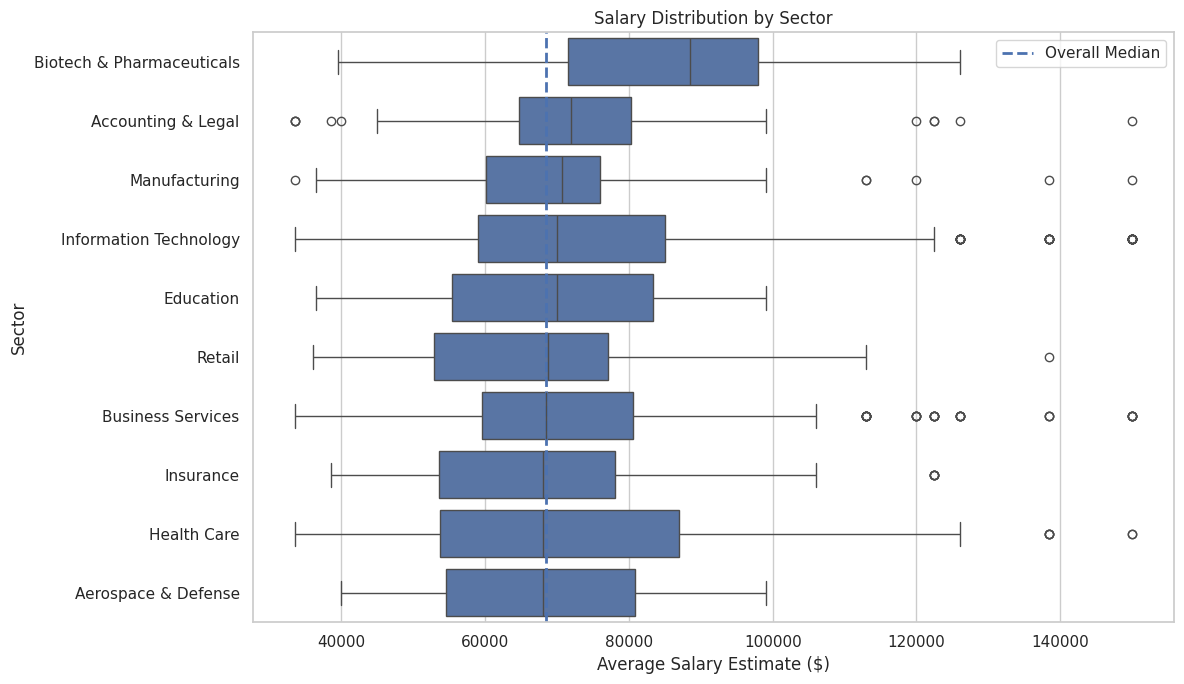

In [9]:
# Salary distribution across top sectors
top_10_sectors = sector_summary.head(10).index.tolist()
df_sector_plot = df_rq1[df_rq1['sector'].isin(top_10_sectors)].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_sector_plot, x='salary_avg', y='sector', order=top_10_sectors)
plt.axvline(df_rq1['salary_avg'].median(), linestyle='--', linewidth=2, label='Overall Median')
plt.title('Salary Distribution by Sector')
plt.xlabel('Average Salary Estimate ($)')
plt.ylabel('Sector')
plt.legend()
plt.tight_layout()
plt.savefig('visuals/rq1_sector_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ANOVA test across top sectors
sector_groups = [
    df_sector_plot[df_sector_plot['sector'] == sector]['salary_avg'].dropna().values
    for sector in top_10_sectors
]

f_stat, p_value = f_oneway(*sector_groups)

print("ANOVA Test: Sector vs Salary")
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Interpretation: Salary differences across these sectors are statistically significant.")
else:
    print("Interpretation: Salary differences across these sectors are not statistically significant.")

ANOVA Test: Sector vs Salary
F-statistic: 1.50
P-value: 0.143774
Interpretation: Salary differences across these sectors are not statistically significant.


**Interpretation note:** Median salary is the main ranking metric because salary distributions can be skewed by very high or very low postings.

## RQ2 — Do higher-revenue companies ask for more technical skills?

**Question:** Is company revenue related to the number of technical skill categories mentioned in job descriptions?  
**Why it matters:** This checks whether larger companies tend to demand broader technical coverage from analysts.

**Method:** Use `revenue_avg_millions`, bucket companies into revenue tiers, and compare average `skill_score`.

In [11]:
df_rq2 = df[df['revenue_avg_millions'].notna() & df['skill_score'].notna()].copy()

bins = [0, 10, 50, 500, 5000, 50000]
labels = ['<$10M', '$10M-$50M', '$50M-$500M', '$500M-$5B', '>$5B']
df_rq2['revenue_tier'] = pd.cut(df_rq2['revenue_avg_millions'], bins=bins, labels=labels)

revenue_skill_summary = (
    df_rq2
    .groupby('revenue_tier', observed=True)
    .agg(
        mean_skill_score=('skill_score', 'mean'),
        median_skill_score=('skill_score', 'median'),
        job_count=('skill_score', 'count')
    )
    .round(2)
)

print(f"Sample size for RQ2: {len(df_rq2):,} rows ({len(df_rq2) / len(df) * 100:.1f}% of dataset)")
revenue_skill_summary

Sample size for RQ2: 1,285 rows (57.1% of dataset)


,mean_skill_score,median_skill_score,job_count
revenue_tier,,,
<$10M,1.61,1.0,276
$10M-$50M,1.97,2.0,241
$50M-$500M,1.82,2.0,417
$500M-$5B,1.84,2.0,295
>$5B,2.23,2.0,56


In [12]:
# Spearman is used because revenue is highly skewed and ordinal-like after parsing
corr, p_value = spearmanr(df_rq2['revenue_avg_millions'], df_rq2['skill_score'])

print("Spearman Correlation: Revenue vs Skill Score")
print(f"Correlation coefficient: {corr:.3f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    direction = "positive" if corr > 0 else "negative"
    print(f"Interpretation: There is a statistically significant {direction} relationship.")
else:
    print("Interpretation: No statistically significant relationship found.")

Spearman Correlation: Revenue vs Skill Score
Correlation coefficient: 0.065
P-value: 0.019572
Interpretation: There is a statistically significant positive relationship.


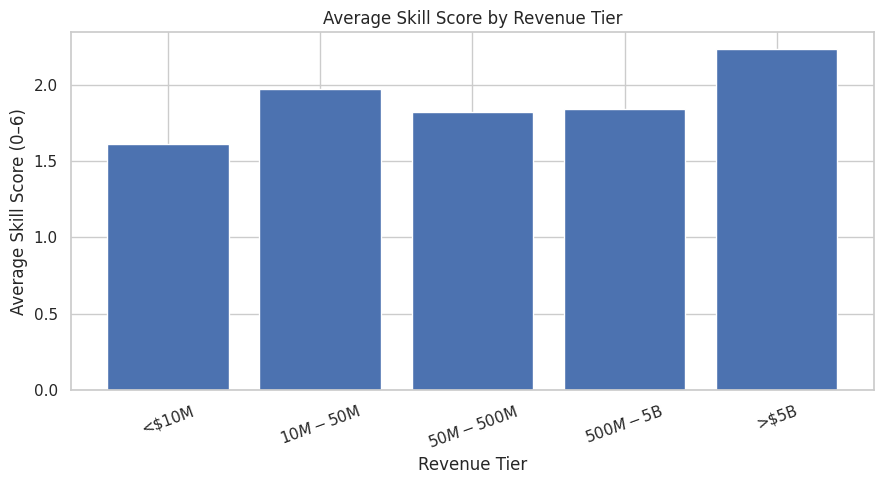

In [13]:
revenue_skill_plot = revenue_skill_summary.reset_index()

plt.figure(figsize=(9, 5))
plt.bar(
    revenue_skill_plot['revenue_tier'].astype(str),
    revenue_skill_plot['mean_skill_score']
)
plt.title('Average Skill Score by Revenue Tier')
plt.xlabel('Revenue Tier')
plt.ylabel('Average Skill Score (0–6)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('visuals/rq2_skill_score_by_revenue_tier.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Optional detail: which skill categories appear most often by revenue tier?
skill_presence_by_revenue = (
    df_rq2
    .groupby('revenue_tier', observed=True)[skill_flag_cols]
    .mean()
    .mul(100)
    .round(1)
)

skill_presence_by_revenue

,skill_data_manipulation,skill_programming,skill_visualization,skill_cloud_platforms,skill_ml_ai,skill_statistics
revenue_tier,,,,,,
<$10M,69.6,24.3,23.6,7.2,9.4,26.4
$10M-$50M,71.8,31.5,36.1,15.8,9.5,32.4
$50M-$500M,79.1,23.0,28.1,7.4,4.8,40.0
$500M-$5B,73.9,24.7,31.9,8.8,7.8,37.3
>$5B,80.4,35.7,44.6,10.7,8.9,42.9


**Interpretation note:** `skill_score` measures breadth of skill categories, not mastery. A posting asking for SQL and Python gets a higher score than SQL alone, but the score does not measure depth or seniority.

## RQ3 — Does location still matter for salary?

**Question:** How do salary estimates vary by state?  
**Why it matters:** Location can influence pay through labor market concentration, cost of living, and company mix.

**Method:** Extract state from `location`, apply a minimum posting threshold, then compare median salaries.

In [15]:
minimum_state_count = 10

df_rq3 = df[df['job_state'].notna() & df['salary_avg'].notna()].copy()

state_summary = (
    df_rq3
    .groupby('job_state')
    .agg(
        median_salary=('salary_avg', 'median'),
        mean_salary=('salary_avg', 'mean'),
        job_count=('salary_avg', 'count')
    )
    .query('job_count >= @minimum_state_count')
    .round(0)
    .sort_values('median_salary', ascending=False)
)

state_summary.head(15)

,median_salary,mean_salary,job_count
job_state,,,
CA,80500.0,88432.0,626
WA,78000.0,64755.0,53
IL,77500.0,78311.0,164
AZ,73500.0,70789.0,97
NJ,71750.0,73000.0,86
CO,70000.0,73619.0,88
NY,69000.0,71412.0,345
NC,68000.0,68022.0,89
TX,61250.0,58751.0,394


In [16]:
# Key finding for RQ3
top_state = state_summary.index[0]
bottom_state = state_summary.index[-1]
state_gap = state_summary.loc[top_state, 'median_salary'] - state_summary.loc[bottom_state, 'median_salary']
state_gap_pct = state_gap / state_summary.loc[bottom_state, 'median_salary'] * 100

print("RQ3 Key Finding")
print(f"Highest-paying state in sample: {top_state} (${state_summary.loc[top_state, 'median_salary']:,.0f})")
print(f"Lowest-paying state in sample: {bottom_state} (${state_summary.loc[bottom_state, 'median_salary']:,.0f})")
print(f"Median salary gap: ${state_gap:,.0f} ({state_gap_pct:.1f}% difference)")

RQ3 Key Finding
Highest-paying state in sample: CA ($80,500)
Lowest-paying state in sample: UT ($36,500)
Median salary gap: $44,000 (120.5% difference)


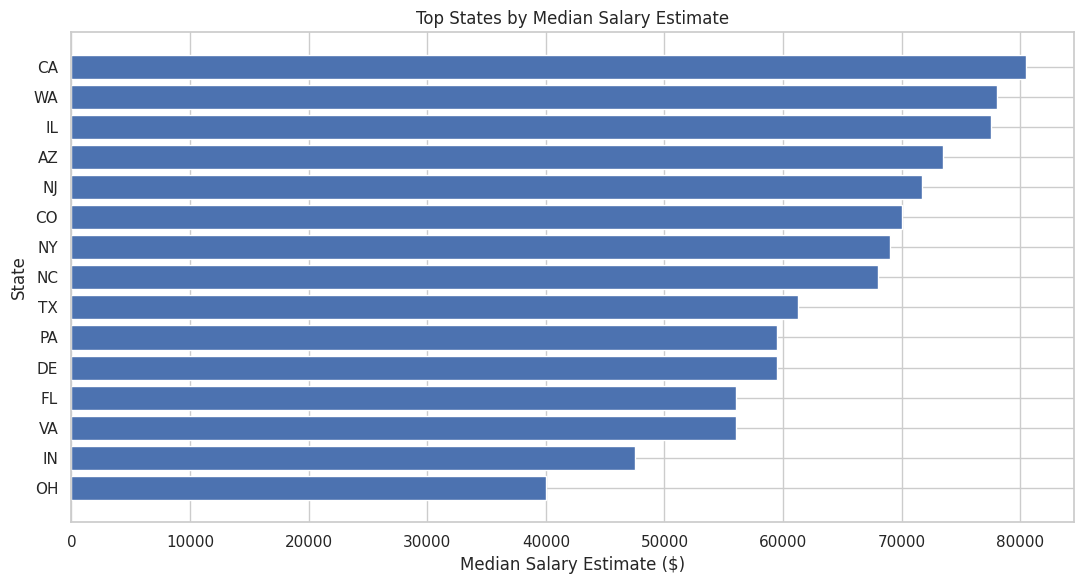

In [17]:
top_states_salary = state_summary.head(15).sort_values('median_salary')

plt.figure(figsize=(11, 6))
plt.barh(top_states_salary.index, top_states_salary['median_salary'])
plt.title('Top States by Median Salary Estimate')
plt.xlabel('Median Salary Estimate ($)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('visuals/rq3_top_states_by_salary.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation note:** State-level comparisons should be read carefully because the dataset reflects job postings, not the full labor market. A minimum sample threshold helps reduce noise from states with very few postings.

## RQ4 — Does company rating relate to salary?

**Question:** Do higher-rated companies pay more, less, or about the same?  
**Why it matters:** This tests a practical tradeoff: reputation and employee satisfaction may not always move in the same direction as pay.

**Method:** Bin company ratings into low, medium, and high groups, then compare median salaries across sectors.

In [18]:
df_rq4 = df[df['rating'].notna() & df['salary_avg'].notna() & df['sector'].notna()].copy()

df_rq4['rating_bin'] = pd.cut(
    df_rq4['rating'],
    bins=[0, 3.0, 4.0, 5.0],
    labels=['Low (<3.0)', 'Medium (3.0–3.9)', 'High (4.0+)'],
    include_lowest=True
)

rating_summary = (
    df_rq4
    .groupby('rating_bin', observed=True)
    .agg(
        median_salary=('salary_avg', 'median'),
        mean_salary=('salary_avg', 'mean'),
        job_count=('salary_avg', 'count')
    )
    .round(0)
)

rating_summary

,median_salary,mean_salary,job_count
rating_bin,,,
Low (<3.0),68000.0,69275.0,227
Medium (3.0–3.9),68250.0,71801.0,1118
High (4.0+),69500.0,73591.0,514


In [19]:
# Compare rating bins inside top sectors with enough postings
top_rated_sectors = (
    df_rq4['sector']
    .value_counts()
    .head(6)
    .index
    .tolist()
)

df_rating_sector = df_rq4[df_rq4['sector'].isin(top_rated_sectors)].copy()

rating_sector_summary = (
    df_rating_sector
    .groupby(['sector', 'rating_bin'], observed=True)
    .agg(
        median_salary=('salary_avg', 'median'),
        job_count=('salary_avg', 'count')
    )
    .reset_index()
)

rating_sector_summary.head(12)

,sector,rating_bin,median_salary,job_count
0,Business Services,Low (<3.0),73500.0,64
1,Business Services,Medium (3.0–3.9),68000.0,293
2,Business Services,High (4.0+),68500.0,154
3,Education,Low (<3.0),77500.0,4
4,Education,Medium (3.0–3.9),65250.0,14
5,Education,High (4.0+),72000.0,33
6,Finance,Low (<3.0),63000.0,19
7,Finance,Medium (3.0–3.9),63000.0,125
8,Finance,High (4.0+),74500.0,22
9,Health Care,Low (<3.0),66500.0,23


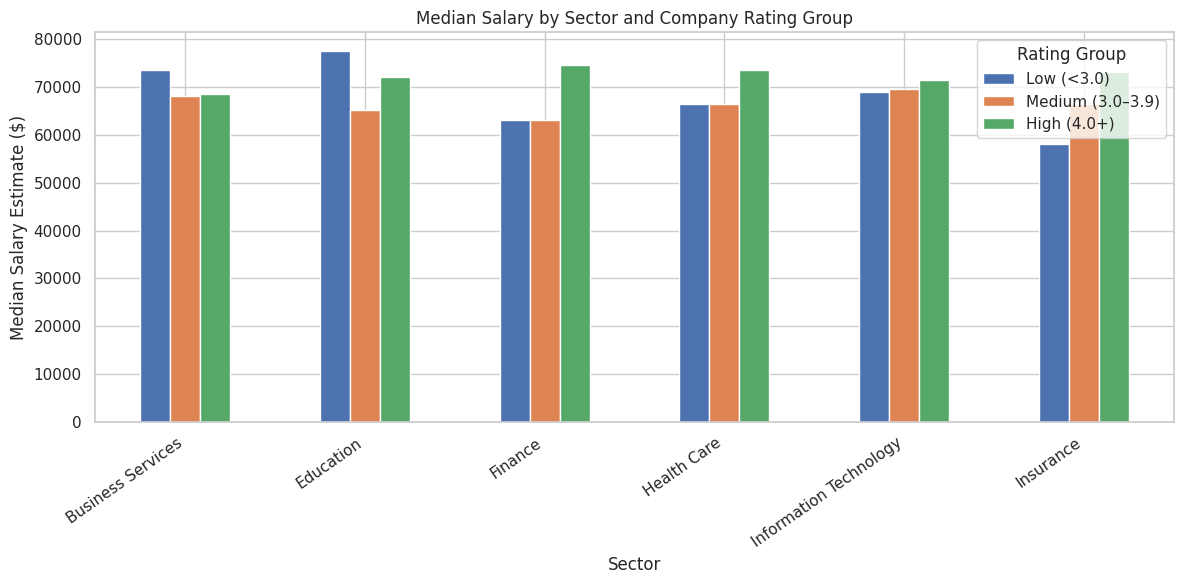

In [20]:
rating_sector_pivot = rating_sector_summary.pivot(index='sector', columns='rating_bin', values='median_salary')

rating_sector_pivot.plot(kind='bar', figsize=(12, 6))
plt.title('Median Salary by Sector and Company Rating Group')
plt.xlabel('Sector')
plt.ylabel('Median Salary Estimate ($)')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Rating Group')
plt.tight_layout()
plt.savefig('visuals/rq4_salary_by_sector_and_rating.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Simple overall relationship between numeric rating and salary
rating_corr = df_rq4[['rating', 'salary_avg']].corr(method='spearman').iloc[0, 1]

print("RQ4 Key Finding")
print(f"Spearman correlation between rating and salary: {rating_corr:.3f}")
print("Interpretation: A value near 0 means rating has weak relationship with salary in this dataset.")

RQ4 Key Finding
Spearman correlation between rating and salary: 0.039
Interpretation: A value near 0 means rating has weak relationship with salary in this dataset.


**Interpretation note:** Company rating is self-reported by employees and may reflect culture, management, workload, or review bias. It should not be treated as a pure quality score.

# Final Insight Summary

This section turns the EDA outputs into case-study language. The goal is not to overclaim. The findings should be framed as patterns from the dataset, not universal truths about every Data Analyst job.

In [22]:
summary_points = pd.DataFrame({
    'question': [
        'RQ1: Sector and salary',
        'RQ2: Revenue and skill complexity',
        'RQ3: Location and salary',
        'RQ4: Rating and salary'
    ],
    'main_signal': [
        f"{top_sector} has the highest median salary among sectors with at least {minimum_sector_count} postings.",
        f"Revenue and skill score correlation: {corr:.3f} with p-value {p_value:.4f}.",
        f"{top_state} has the highest median salary among states with at least {minimum_state_count} postings.",
        f"Rating and salary correlation: {rating_corr:.3f}."
    ],
    'portfolio_interpretation': [
        'Sector appears to be a meaningful salary segmentation lens.',
        'Company revenue alone is not enough; skill breadth should be checked directly from job descriptions.',
        'Geography still matters, but sample size and company mix should be considered.',
        'Company reputation should be evaluated separately from compensation.'
    ]
})

summary_points

,question,main_signal,portfolio_interpretation
0,RQ1: Sector and salary,Biotech & Pharmaceuticals has the highest medi...,Sector appears to be a meaningful salary segme...
1,RQ2: Revenue and skill complexity,Revenue and skill score correlation: 0.065 wit...,Company revenue alone is not enough; skill bre...
2,RQ3: Location and salary,CA has the highest median salary among states ...,"Geography still matters, but sample size and c..."
3,RQ4: Rating and salary,Rating and salary correlation: 0.039.,Company reputation should be evaluated separat...


## Portfolio Takeaway

A strong job-market analysis should not only ask “which roles pay more?” It should separate salary drivers into explainable dimensions: sector, company size/revenue, location, skill demand, and reputation.

For this dataset, the analysis suggests that salary strategy should be built around **where the role sits in the market** — not only the job title. A Data Analyst role can look very different depending on sector, location, and the technical expectations in the job description.

# Limitations & Next Steps

## Limitations

1. **Glassdoor salary estimates** — Salary ranges are estimates, not confirmed compensation.
2. **Cross-sectional dataset** — The data shows one snapshot, not salary trends over time.
3. **Missing company metadata** — Revenue, rating, sector, and industry fields have missing values.
4. **Skill extraction is keyword-based** — The skill score detects keyword presence, not depth of expertise.
5. **Location analysis is US-focused** — The results should not be generalized globally.

## Recommended next steps

1. Add cost-of-living adjustment for location analysis.
2. Compare salary patterns by seniority level.
3. Build a focused Power BI dashboard using the cleaned dataset.
4. Turn the four research questions into a concise portfolio case study page.